Main Functions

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [156]:
# Preprocesses the data into pandas dataframes which then can be read easier
def preprocessData(df, descriptionUse):
    if descriptionUse == True:
        # Only takes the items "gender", "text", and "description" from each user in the csv
        df = df[["gender", "text", "description"]]
    else:
        # Only takes the items "gender", "text" from each user in the csv
        df = df[["gender", "text"]]
    # Drops the user's data from the dataframe if the there is no "gender" or "text"
    df = df.dropna(subset=["gender", "text"])
    # Ensures "gender" must be "male" or "female"
    df = df[df["gender"].isin(["male", "female"])]
    # Fills NaN values in "text" with ""
    df["text"] = df["text"].fillna("")
    if descriptionUse == True:
        #Fills NaN values in "description" with ""
        df["description"] = df["description"].fillna("")
        # Combines text and description to save time
        df["overallTextData"] = df["text"] + " " + df["description"]  # Concatenate them
    else:
        df["overallTextData"] = df["text"]
    # Makes numbers from genders, where male = 0 and female = 1
    df["genderNums"] = df["gender"].map({"male": 0, "female": 1})
    return df[["overallTextData", "genderNums"]]

In [157]:
# Trains data and determines metrics
def getMetrics(df, classifierType, k):
    # Lists to store metrics over each of the folds
    accuracyMetrics = []
    precisionMetrics = []
    recallMetrics = []
    # Defines Kfolds with and a constant "randomness" and shuffling
    kFolds = KFold(n_splits = k, random_state = 1, shuffle = True)
    # Loop through each fold
    for i, j in kFolds.split(df):
        # Splits up the data
        trainingSet = df.iloc[i]
        testingSet = df.iloc[j]
        # Converts the information into TF-IDF features
        # Max features are 5000 because 10000 takes too long
        # ngram range(1,2) is used because this allows for unigrams and bigrams
        # stop_words = "english" removes words like "is", "and", "the" because they are just noise
        vectorizer = TfidfVectorizer(max_features = 5000, ngram_range = (1, 2), stop_words = "english")
        trainTFIDF = vectorizer.fit_transform(trainingSet["overallTextData"])
        testTFIDF = vectorizer.transform(testingSet["overallTextData"])
        # Select classifier based on our input
        # THIS IS KEPT IN FOR TESTING PURPOSES, SVM PERFORMED WORSE THAN NB IN THIS CASE SO WE ONLY USE NB
        if classifierType == "SVM":
            classifier = SVC(kernel = "linear")
        elif classifierType == "NB":
            classifier = MultinomialNB()
        # Trains and classifier and predicts test data
        classifier.fit(trainTFIDF, trainingSet["genderNums"])
        prediction = classifier.predict(testTFIDF)
        # Finds requested metrics and adds to their corresponding lists (multiplied by 100 so they can be displayed as % later on)
        accuracyMetrics.append(accuracy_score(testingSet["genderNums"], prediction) * 100)
        precisionMetrics.append(precision_score(testingSet["genderNums"], prediction) * 100)
        recallMetrics.append(recall_score(testingSet["genderNums"], prediction) * 100)
    return [accuracyMetrics, sum(accuracyMetrics) / len(accuracyMetrics), precisionMetrics, 
            sum(precisionMetrics) / len(precisionMetrics), recallMetrics, sum(recallMetrics) / len(recallMetrics)]



In [158]:
# Function to set up plot to display a graph for a metric and prints data below
def plot_metrics(classifier, metric, metricData, metricAverage, kFolds):
    plt.figure(figsize=(6, 5))
    plt.title(metric + " for each K-Fold Iteration on " + classifier)
    plt.xlabel("K-Fold Iteration")
    plt.ylabel(metric + " (%)")
    plt.xticks(kFolds)
    plt.ylim(0, 100)
    plt.bar(kFolds, metricData, color = "blue")
    plt.axhline(y = metricAverage, label = "Avg " + metric + ": " + f"{metricAverage:.2f}" + "%", linestyle="--", color = "red")
    plt.legend()
    for i in kFolds:
        print(metric + " for K-Fold Iteration " + str(i) + " on " + classifier + ": " + f"{metricData[i-1]:.2f}" + "%")
    print("Average " + metric + " across all K-Folds: " + f"{metricAverage:.2f}" + "%\n")

HW2 Dataset Results:

Accuracy for K-Fold Iteration 1 on Naïve Bayes: 67.04%
Accuracy for K-Fold Iteration 2 on Naïve Bayes: 66.61%
Accuracy for K-Fold Iteration 3 on Naïve Bayes: 67.93%
Accuracy for K-Fold Iteration 4 on Naïve Bayes: 65.84%
Accuracy for K-Fold Iteration 5 on Naïve Bayes: 67.11%
Average Accuracy across all K-Folds: 66.91%

Precision for K-Fold Iteration 1 on Naïve Bayes: 66.87%
Precision for K-Fold Iteration 2 on Naïve Bayes: 64.89%
Precision for K-Fold Iteration 3 on Naïve Bayes: 66.78%
Precision for K-Fold Iteration 4 on Naïve Bayes: 65.28%
Precision for K-Fold Iteration 5 on Naïve Bayes: 66.25%
Average Precision across all K-Folds: 66.01%

Recall for K-Fold Iteration 1 on Naïve Bayes: 74.15%
Recall for K-Fold Iteration 2 on Naïve Bayes: 75.76%
Recall for K-Fold Iteration 3 on Naïve Bayes: 75.26%
Recall for K-Fold Iteration 4 on Naïve Bayes: 74.50%
Recall for K-Fold Iteration 5 on Naïve Bayes: 74.76%
Average Recall across all K-Folds: 74.89%



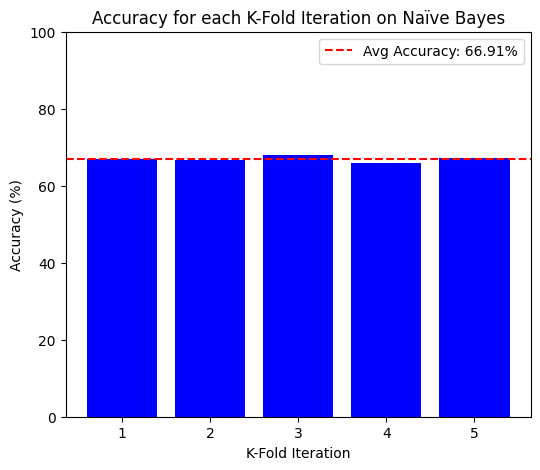

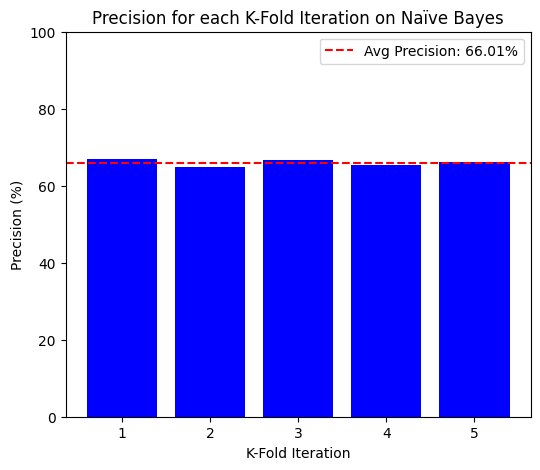

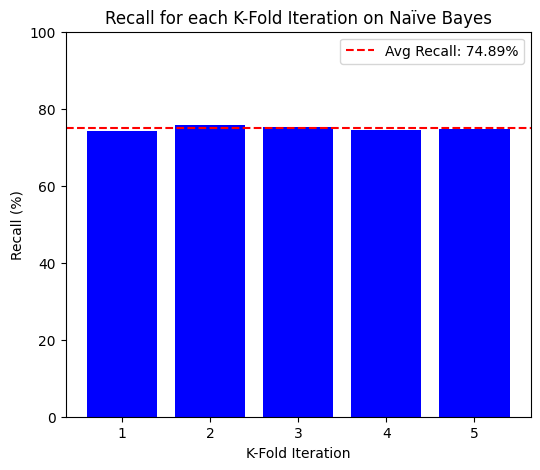

In [159]:
# Running/Obtaining output for HW2 dataset!
df = pd.read_csv("gender-classifier-DFE-791531.csv", encoding="latin1")
df_new = preprocessData(df, True)
k = 5  # Number of folds
kFolds = list(range(1, k + 1))
NB_metrics = getMetrics(df_new, "NB", k)
# Makes graphs for each of the 3 metrics
plot_metrics("Naïve Bayes", "Accuracy", NB_metrics[0], NB_metrics[1], kFolds)
plot_metrics("Naïve Bayes", "Precision", NB_metrics[2], NB_metrics[3], kFolds)
plot_metrics("Naïve Bayes", "Recall", NB_metrics[4], NB_metrics[5], kFolds)

In [ ]:
""" 
This code was added to test effectives of SVM in contrast to NB.
This code does not need to be run as it is not part of the end report
because SVM performed slightly worse than NB with a longer runtime
"""
SVM_metrics = getMetrics(df_new, "SVM", k)
# Makes graphs for each of the 3 metrics
plot_metrics("Support Vector Machine", "Accuracy", SVM_metrics[0], SVM_metrics[1], kFolds)
plot_metrics("Support Vector Machine", "Precision", SVM_metrics[2], SVM_metrics[3], kFolds)
plot_metrics("Support Vector Machine", "Recall", SVM_metrics[4], SVM_metrics[5], kFolds)

HW1 Dataset Results/Parsing

In [161]:
# Lists created from "Male-Female-Names-1.pdf"
male_name_list = ["luke", "ted", "david", "matthew", "jake", "rick", "josh", "tony", "aaron", "michael", "nick", "george", "john"]
female_name_list = ["judith", "tia", "meg", "vicky", "eva", "julie", "rita", "leah", "caroline", "cintihia", "ariel", "macy", "lynn", "rebecca", "cinthia", "mara", "amy", "michelle"] 

# Function parses the text files to mimic the existing csv for hw2 (looking for names - which can be used to find gender, and text)
def parseHW1Files(fileName):
    gender_list = []
    texts_list = []
    convoFile = open(fileName, "r")
    for line in convoFile:
        name = line.split(" (", 1)[0]
        if name in male_name_list:
            gender_list.append("male")
        elif name in female_name_list:
            gender_list.append("female")
        else:
            # To make things easier names that are not in both lists are considered a brand since they will be removed later anyway
            gender_list.append("brand")
        lineRemainder = line.split(" (", 1)[1]
        content = lineRemainder.split("M):  ", 1)[1]
        texts_list.append(content)
    convoFile.close()
    return gender_list, texts_list

Accuracy for K-Fold Iteration 1 on Naïve Bayes: 85.19%
Accuracy for K-Fold Iteration 2 on Naïve Bayes: 90.12%
Accuracy for K-Fold Iteration 3 on Naïve Bayes: 92.59%
Accuracy for K-Fold Iteration 4 on Naïve Bayes: 82.50%
Accuracy for K-Fold Iteration 5 on Naïve Bayes: 88.75%
Average Accuracy across all K-Folds: 87.83%

Precision for K-Fold Iteration 1 on Naïve Bayes: 85.19%
Precision for K-Fold Iteration 2 on Naïve Bayes: 90.12%
Precision for K-Fold Iteration 3 on Naïve Bayes: 92.59%
Precision for K-Fold Iteration 4 on Naïve Bayes: 82.50%
Precision for K-Fold Iteration 5 on Naïve Bayes: 88.75%
Average Precision across all K-Folds: 87.83%

Recall for K-Fold Iteration 1 on Naïve Bayes: 100.00%
Recall for K-Fold Iteration 2 on Naïve Bayes: 100.00%
Recall for K-Fold Iteration 3 on Naïve Bayes: 100.00%
Recall for K-Fold Iteration 4 on Naïve Bayes: 100.00%
Recall for K-Fold Iteration 5 on Naïve Bayes: 100.00%
Average Recall across all K-Folds: 100.00%



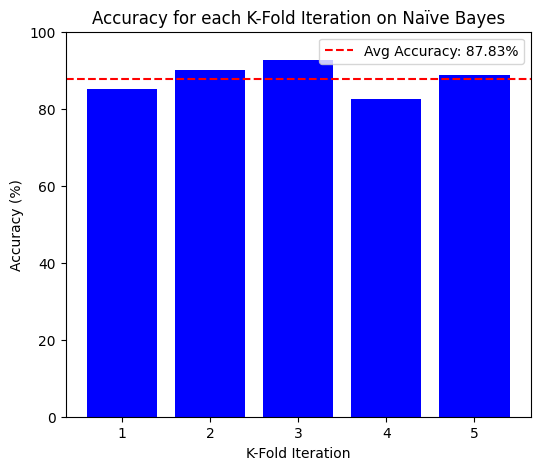

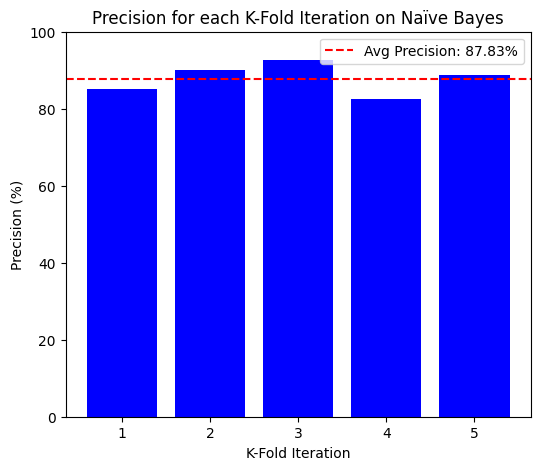

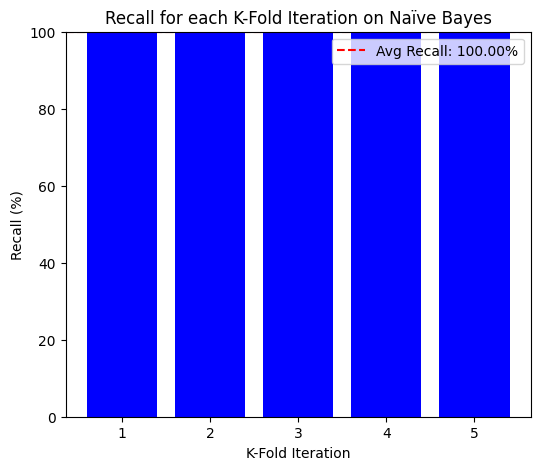

In [162]:
# Creating dataframe from txt files
gender_list, texts_list = parseHW1Files("Feb17_GroupA.txt")
data = {
    "gender": gender_list,
    "text": texts_list
}
df = pd.DataFrame(data)
df_new = preprocessData(df, False)
k = 5  # Number of folds
kFolds = list(range(1, k + 1))
NB_metrics = getMetrics(df_new, "NB", k)
# Makes graphs for each of the 3 metrics for NB and SVM
plot_metrics("Naïve Bayes", "Accuracy", NB_metrics[0], NB_metrics[1], kFolds)
plot_metrics("Naïve Bayes", "Precision", NB_metrics[2], NB_metrics[3], kFolds)
plot_metrics("Naïve Bayes", "Recall", NB_metrics[4], NB_metrics[5], kFolds)

In [ ]:
""" 
This code was added to test effectives of SVM in contrast to NB.
This code does not need to be run as it is not part of the end report
because SVM performed slightly worse than NB with a longer runtime
"""
SVM_metrics = getMetrics(df_new, "SVM", k)
# Makes graphs for each of the 3 metrics
plot_metrics("Support Vector Machine", "Accuracy", SVM_metrics[0], SVM_metrics[1], kFolds)
plot_metrics("Support Vector Machine", "Precision", SVM_metrics[2], SVM_metrics[3], kFolds)
plot_metrics("Support Vector Machine", "Recall", SVM_metrics[4], SVM_metrics[5], kFolds)

Accuracy for K-Fold Iteration 1 on Naïve Bayes: 59.35%
Accuracy for K-Fold Iteration 2 on Naïve Bayes: 66.39%
Accuracy for K-Fold Iteration 3 on Naïve Bayes: 68.03%
Accuracy for K-Fold Iteration 4 on Naïve Bayes: 66.39%
Accuracy for K-Fold Iteration 5 on Naïve Bayes: 65.57%
Average Accuracy across all K-Folds: 65.15%

Precision for K-Fold Iteration 1 on Naïve Bayes: 61.54%
Precision for K-Fold Iteration 2 on Naïve Bayes: 61.96%
Precision for K-Fold Iteration 3 on Naïve Bayes: 70.13%
Precision for K-Fold Iteration 4 on Naïve Bayes: 64.52%
Precision for K-Fold Iteration 5 on Naïve Bayes: 62.11%
Average Precision across all K-Folds: 64.05%

Recall for K-Fold Iteration 1 on Naïve Bayes: 78.87%
Recall for K-Fold Iteration 2 on Naïve Bayes: 90.48%
Recall for K-Fold Iteration 3 on Naïve Bayes: 77.14%
Recall for K-Fold Iteration 4 on Naïve Bayes: 88.24%
Recall for K-Fold Iteration 5 on Naïve Bayes: 90.77%
Average Recall across all K-Folds: 85.10%



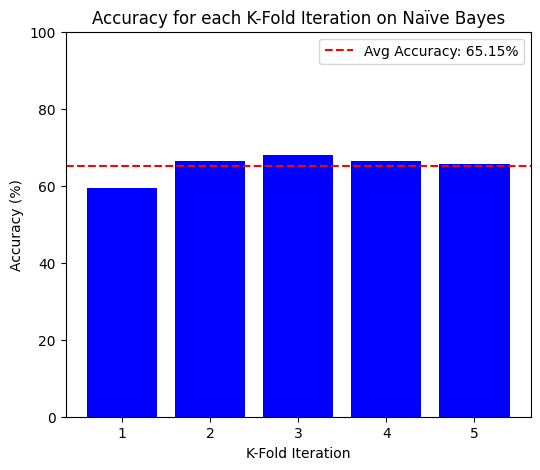

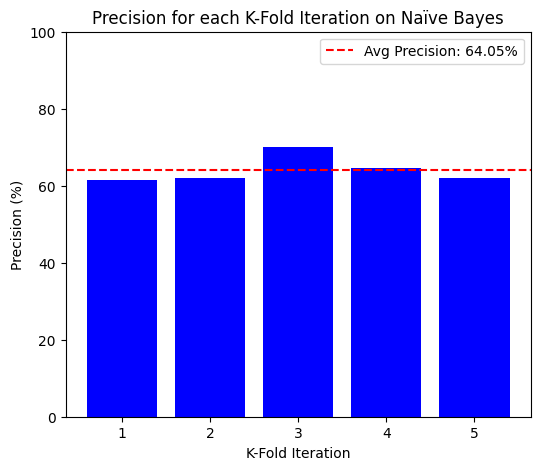

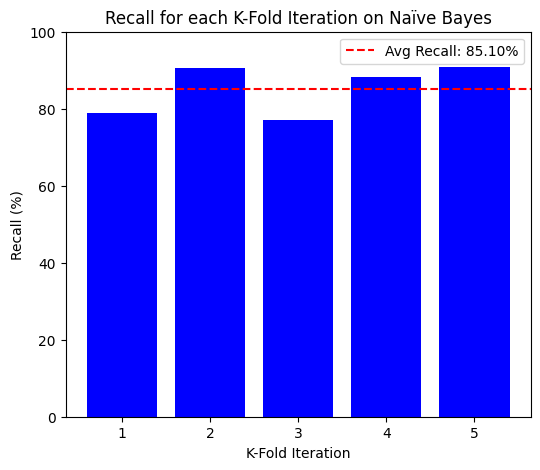

In [164]:
# Creating dataframe from txt files
gender_list, texts_list = parseHW1Files("Feb17_GroupB.txt")
data = {
    "gender": gender_list,
    "text": texts_list
}
df = pd.DataFrame(data)
df_new = preprocessData(df, False)
k = 5  # Number of folds
kFolds = list(range(1, k + 1))
NB_metrics = getMetrics(df_new, "NB", k)
# Makes graphs for each of the 3 metrics for NB and SVM
plot_metrics("Naïve Bayes", "Accuracy", NB_metrics[0], NB_metrics[1], kFolds)
plot_metrics("Naïve Bayes", "Precision", NB_metrics[2], NB_metrics[3], kFolds)
plot_metrics("Naïve Bayes", "Recall", NB_metrics[4], NB_metrics[5], kFolds)

In [ ]:
""" 
This code was added to test effectives of SVM in contrast to NB.
This code does not need to be run as it is not part of the end report
because SVM performed slightly worse than NB with a longer runtime
"""
SVM_metrics = getMetrics(df_new, "SVM", k)
# Makes graphs for each of the 3 metrics
plot_metrics("Support Vector Machine", "Accuracy", SVM_metrics[0], SVM_metrics[1], kFolds)
plot_metrics("Support Vector Machine", "Precision", SVM_metrics[2], SVM_metrics[3], kFolds)
plot_metrics("Support Vector Machine", "Recall", SVM_metrics[4], SVM_metrics[5], kFolds)